In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 解決 matplotlib 中文顯示問題
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macOS 使用 Arial Unicode MS
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

data = pd.read_csv('data_choice_complete.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45211 non-null  float64
 1   job        45211 non-null  float64
 2   marital    45211 non-null  float64
 3   education  45211 non-null  float64
 4   balance    45211 non-null  float64
 5   housing    45211 non-null  float64
 6   loan       45211 non-null  float64
 7   month      45211 non-null  float64
 8   duration   45211 non-null  float64
 9   campaign   45211 non-null  float64
 10  y          45211 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 3.8 MB


In [19]:
from sklearn.model_selection import train_test_split

X=data.drop('y', axis=1)
y=data['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((36168, 10), (9043, 10), (36168,), (9043,))

# SVM 模型訓練

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import time

# SVM 對特徵縮放敏感，先進行標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 記錄開始時間
start_time = time.time()

# 使用 GridSearchCV 調整 C 和 kernel 參數
param_grid = {
    'C': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly'],
    'degree': [2, 3, 4, 5],  # 多項式核函數的 degree 參數
    'gamma': [0.001, 0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    SVC(random_state=100, probability=True),  # probability=True 用於後續 ROC curve
    param_grid,
    cv=10,  # 用 CV 評估每組參數的表現
    scoring='accuracy',
    n_jobs=-1
)

print("開始 GridSearchCV 訓練...")
grid_search.fit(X_train_scaled, y_train)
print(f"最佳參數: {grid_search.best_params_}")

# 建立 SVM 模型
svm_model = grid_search.best_estimator_

# 計算訓練時間
end_time = time.time()
training_time = end_time - start_time

# 預測
y_pred_svm = svm_model.predict(X_test_scaled)

# 計算準確率
svm_acc = accuracy_score(y_test, y_pred_svm)

# 輸出結果
print("\n" + "=" * 60)
print("SVM 訓練結果:")
print("=" * 60)
print(f"訓練時間: {training_time:.4f} 秒 ({training_time:.2f}s)")
print(f"準確率:   {svm_acc:.4f} ({svm_acc*100:.2f}%)")
print("\n分類報告:")
print(classification_report(y_test, y_pred_svm))

開始 GridSearchCV 訓練...


/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


## 混淆矩陣

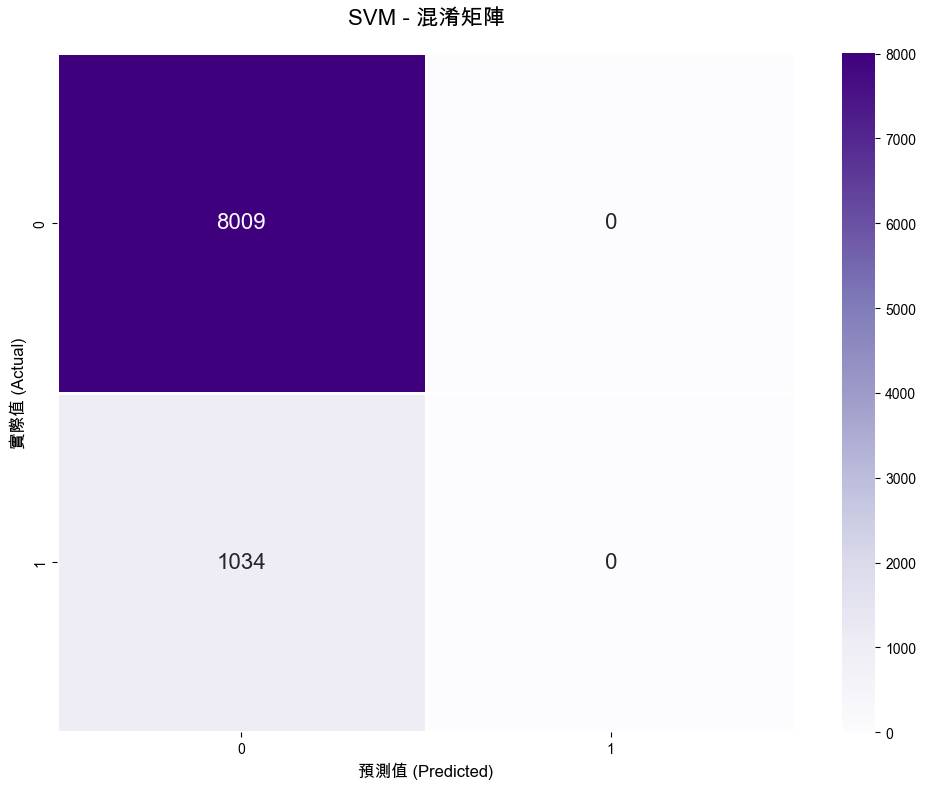

混淆矩陣分析:

True Negative (TN):   8009 - 正確預測為「未訂閱」
False Positive (FP):     0 - 錯誤預測為「訂閱」(Type I Error)
False Negative (FN):  1034 - 錯誤預測為「未訂閱」(Type II Error)
True Positive (TP):      0 - 正確預測為「訂閱」

從混淆矩陣計算的評估指標:
準確率 (Accuracy):    0.8857 (88.57%)
  → (TP + TN) / 總數 = (0 + 8009) / 9043

精確率 (Precision):   0.0000 (0.00%)
  → TP / (TP + FP) = 0 / (0 + 0)
  → 預測為「訂閱」中，真正訂閱的比例

召回率 (Recall):      0.0000 (0.00%)
  → TP / (TP + FN) = 0 / (0 + 1034)
  → 實際「訂閱」中，被正確找出的比例

特異度 (Specificity): 1.0000 (100.00%)
  → TN / (TN + FP) = 8009 / (8009 + 0)
  → 實際「未訂閱」中，被正確識別的比例

F1 分數 (F1-Score):   0.0000
  → 2 × (Precision × Recall) / (Precision + Recall)

業務意義解讀:
• Type I Error (FP=0):  誤判為會訂閱 → 浪費行銷資源
• Type II Error (FN=1034): 漏掉潛在客戶 → 失去商機
• 如果重視「不錯過客戶」→ 提高 Recall (降低 FN)
• 如果重視「精準行銷」→ 提高 Precision (降低 FP)


In [ ]:
# 視覺化 SVM 的混淆矩陣
plt.figure(figsize=(10, 8))
cm_svm = confusion_matrix(y_test, y_pred_svm)

# 繪製混淆矩陣熱力圖
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', cbar=True, 
            annot_kws={'size': 16}, linewidths=2, linecolor='white')
plt.title('SVM - 混淆矩陣', fontsize=16, pad=20)
plt.ylabel('實際值 (Actual)', fontsize=12)
plt.xlabel('預測值 (Predicted)', fontsize=12)
plt.tight_layout()
plt.show()

# 詳細分析混淆矩陣
print("=" * 60)
print("混淆矩陣分析:")
print("=" * 60)

# 假設是二元分類 (0: 未訂閱, 1: 訂閱)
TN = cm_svm[0, 0]  # True Negative: 正確預測為 0
FP = cm_svm[0, 1]  # False Positive: 錯誤預測為 1 (Type I Error)
FN = cm_svm[1, 0]  # False Negative: 錯誤預測為 0 (Type II Error)
TP = cm_svm[1, 1]  # True Positive: 正確預測為 1

print(f"\nTrue Negative (TN):  {TN:5d} - 正確預測為「未訂閱」")
print(f"False Positive (FP): {FP:5d} - 錯誤預測為「訂閱」(Type I Error)")
print(f"False Negative (FN): {FN:5d} - 錯誤預測為「未訂閱」(Type II Error)")
print(f"True Positive (TP):  {TP:5d} - 正確預測為「訂閱」")

# 計算各項指標
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\n" + "=" * 60)
print("從混淆矩陣計算的評估指標:")
print("=" * 60)
print(f"準確率 (Accuracy):    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  → (TP + TN) / 總數 = ({TP} + {TN}) / {TP+TN+FP+FN}")
print(f"\n精確率 (Precision):   {precision:.4f} ({precision*100:.2f}%)")
print(f"  → TP / (TP + FP) = {TP} / ({TP} + {FP})")
print(f"  → 預測為「訂閱」中，真正訂閱的比例")
print(f"\n召回率 (Recall):      {recall:.4f} ({recall*100:.2f}%)")
print(f"  → TP / (TP + FN) = {TP} / ({TP} + {FN})")
print(f"  → 實際「訂閱」中，被正確找出的比例")
print(f"\n特異度 (Specificity): {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  → TN / (TN + FP) = {TN} / ({TN} + {FP})")
print(f"  → 實際「未訂閱」中，被正確識別的比例")
print(f"\nF1 分數 (F1-Score):   {f1:.4f}")
print(f"  → 2 × (Precision × Recall) / (Precision + Recall)")

print("\n" + "=" * 60)
print("業務意義解讀:")
print("=" * 60)
print(f"• Type I Error (FP={FP}):  誤判為會訂閱 → 浪費行銷資源")
print(f"• Type II Error (FN={FN}): 漏掉潛在客戶 → 失去商機")
print(f"• 如果重視「不錯過客戶」→ 提高 Recall (降低 FN)")
print(f"• 如果重視「精準行銷」→ 提高 Precision (降低 FP)")

# ROC Curve & AUC

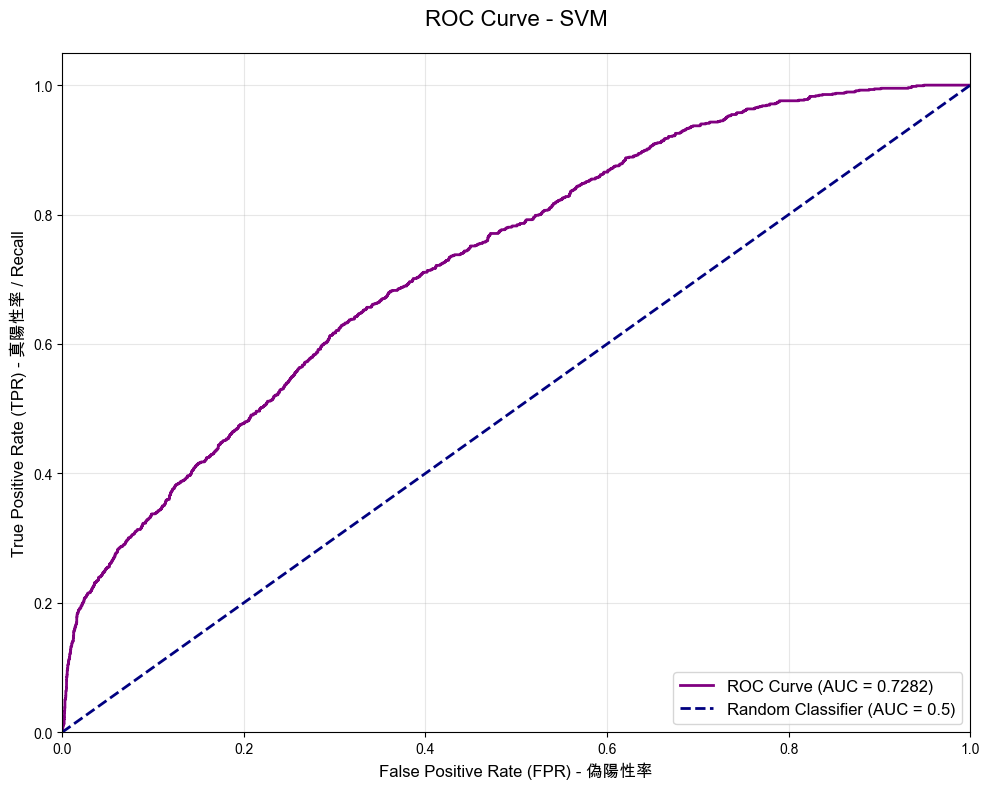

ROC Curve & AUC 分析結果:

AUC (Area Under Curve) 分數: 0.7282
  → AUC 範圍: 0.0 ~ 1.0
  → AUC = 1.0: 完美分類器
  → AUC = 0.5: 隨機猜測（無預測能力）
  → AUC < 0.5: 比隨機猜測還差

ROC Curve 解讀:
• X 軸 (FPR): False Positive Rate = FP / (FP + TN)
  → 實際為「未訂閱」中，被誤判為「訂閱」的比例

• Y 軸 (TPR): True Positive Rate = TP / (TP + FN) = Recall
  → 實際為「訂閱」中，被正確找出的比例

• 曲線越靠近左上角越好（高 TPR、低 FPR）
• 藍色虛線：隨機分類器的基準線
• 紫色實線：SVM 模型表現

AUC 評估標準:
○ AUC = 0.7282 → 尚可 (Fair)

業務應用:
• 可調整分類閾值（threshold）來平衡 FPR 與 TPR
• 降低閾值 → 提高 TPR (找到更多訂閱客戶) 但 FPR 也上升
• 提高閾值 → 降低 FPR (減少誤判) 但 TPR 也下降
• 預設閾值 = 0.5，可根據業務需求調整

不同閾值下的 TPR 與 FPR (前 5 個閾值):
      閾值 |    TPR (Recall) |        FPR
----------------------------------------
     inf |          0.0000 |     0.0000
  0.9128 |          0.0000 |     0.0001
  0.8980 |          0.0010 |     0.0001
  0.8890 |          0.0010 |     0.0002
  0.8758 |          0.0039 |     0.0002


In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# 取得預測機率（正類的機率）
y_pred_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

# 計算 ROC 曲線的數據點
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 計算 AUC 分數
roc_auc = auc(fpr, tpr)

# 繪製 ROC 曲線
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='purple', lw=2, 
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR) - 偽陽性率', fontsize=12)
plt.ylabel('True Positive Rate (TPR) - 真陽性率 / Recall', fontsize=12)
plt.title('ROC Curve - SVM', fontsize=16, pad=20)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 詳細說明
print("=" * 70)
print("ROC Curve & AUC 分析結果:")
print("=" * 70)
print(f"\nAUC (Area Under Curve) 分數: {roc_auc:.4f}")
print(f"  → AUC 範圍: 0.0 ~ 1.0")
print(f"  → AUC = 1.0: 完美分類器")
print(f"  → AUC = 0.5: 隨機猜測（無預測能力）")
print(f"  → AUC < 0.5: 比隨機猜測還差")

print("\n" + "=" * 70)
print("ROC Curve 解讀:")
print("=" * 70)
print("• X 軸 (FPR): False Positive Rate = FP / (FP + TN)")
print("  → 實際為「未訂閱」中，被誤判為「訂閱」的比例")
print("\n• Y 軸 (TPR): True Positive Rate = TP / (TP + FN) = Recall")
print("  → 實際為「訂閱」中，被正確找出的比例")
print("\n• 曲線越靠近左上角越好（高 TPR、低 FPR）")
print("• 藍色虛線：隨機分類器的基準線")
print("• 紫色實線：SVM 模型表現")

print("\n" + "=" * 70)
print("AUC 評估標準:")
print("=" * 70)
if roc_auc >= 0.9:
    print(f"✓ AUC = {roc_auc:.4f} → 優秀 (Excellent)")
elif roc_auc >= 0.8:
    print(f"✓ AUC = {roc_auc:.4f} → 良好 (Good)")
elif roc_auc >= 0.7:
    print(f"○ AUC = {roc_auc:.4f} → 尚可 (Fair)")
elif roc_auc >= 0.6:
    print(f"△ AUC = {roc_auc:.4f} → 不佳 (Poor)")
else:
    print(f"✗ AUC = {roc_auc:.4f} → 失敗 (Fail)")

print("\n" + "=" * 70)
print("業務應用:")
print("=" * 70)
print("• 可調整分類閾值（threshold）來平衡 FPR 與 TPR")
print("• 降低閾值 → 提高 TPR (找到更多訂閱客戶) 但 FPR 也上升")
print("• 提高閾值 → 降低 FPR (減少誤判) 但 TPR 也下降")
print(f"• 預設閾值 = 0.5，可根據業務需求調整")

# 顯示幾個關鍵閾值點
print("\n" + "=" * 70)
print("不同閾值下的 TPR 與 FPR (前 5 個閾值):")
print("=" * 70)
print(f"{'閾值':>8} | {'TPR (Recall)':>15} | {'FPR':>10}")
print("-" * 40)
for i in range(min(5, len(thresholds))):
    print(f"{thresholds[i]:>8.4f} | {tpr[i]:>15.4f} | {fpr[i]:>10.4f}")

## SVM 模型特性說明

**Support Vector Machine (SVM) 是什麼？**
- 尋找最佳的「決策邊界」來分隔不同類別
- 透過「支持向量」(Support Vectors) 定義邊界
- 可以處理非線性問題（使用核函數 kernel）

**主要參數：**
1. **C (懲罰參數)**：
   - 控制分類錯誤的容忍度
   - C 越大 → 越不容忍錯誤 → 可能過擬合
   - C 越小 → 容忍更多錯誤 → 決策邊界更平滑

2. **kernel (核函數)**：
   - `linear`: 線性核，適合線性可分的資料
   - `rbf`: 徑向基函數，適合非線性資料（最常用）
   - `poly`: 多項式核

3. **gamma**：
   - 控制單一樣本的影響範圍
   - gamma 越大 → 影響範圍越小 → 可能過擬合
   - `scale`: 1 / (n_features × X.var())
   - `auto`: 1 / n_features

**SVM 的優缺點：**

✓ 優點：
- 在高維空間中表現良好
- 對於非線性問題有很好的處理能力（使用 kernel trick）
- 記憶體效率高（只需儲存支持向量）
- 泛化能力強，不容易過擬合

✗ 缺點：
- 訓練時間較長（尤其是大數據集）
- 對特徵縮放敏感（必須標準化）
- 參數調整較複雜（C、kernel、gamma）
- 不直接提供機率輸出（需設定 probability=True，但會增加計算時間）